In [2]:
from transformers import CLIPProcessor, CLIPModel, CLIPConfig
import datasets
import clip
import torch
import random

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
config = CLIPConfig.from_pretrained("openai/clip-vit-base-patch32")
my_model = CLIPModel.from_pretrained("../finetuned-clip.pth", config=config)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

oai_model, oai_preprocess = clip.load("ViT-B/32", device="cuda")

Some weights of the model checkpoint at ../finetuned-clip.pth were not used when initializing CLIPModel: ['ln_final.bias', 'ln_final.weight', 'positional_embedding', 'text_projection', 'token_embedding.weight', 'transformer.resblocks.0.attn.in_proj_bias', 'transformer.resblocks.0.attn.in_proj_weight', 'transformer.resblocks.0.attn.out_proj.bias', 'transformer.resblocks.0.attn.out_proj.weight', 'transformer.resblocks.0.ln_1.bias', 'transformer.resblocks.0.ln_1.weight', 'transformer.resblocks.0.ln_2.bias', 'transformer.resblocks.0.ln_2.weight', 'transformer.resblocks.0.mlp.c_fc.bias', 'transformer.resblocks.0.mlp.c_fc.weight', 'transformer.resblocks.0.mlp.c_proj.bias', 'transformer.resblocks.0.mlp.c_proj.weight', 'transformer.resblocks.1.attn.in_proj_bias', 'transformer.resblocks.1.attn.in_proj_weight', 'transformer.resblocks.1.attn.out_proj.bias', 'transformer.resblocks.1.attn.out_proj.weight', 'transformer.resblocks.1.ln_1.bias', 'transformer.resblocks.1.ln_1.weight', 'transformer.resb

In [4]:
dataset = datasets.load_dataset("armaggheddon97/lego_minifigure_captions", split="train")

In [59]:
def my_model_classify(image, captions, print_scores=False):
    inputs = processor(text=captions, images=image, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        outputs = my_model(**inputs)
    
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1).cpu().numpy()
    if print_scores:
        print("Captions with scores for dataset[0]:")
        for caption, prob in zip(captions, probs.flatten().tolist()):
            print(f"[{prob*100:.1f}%]: \"{caption}\"")
    return probs.flatten()

In [61]:
def oai_model_classify(image, captions, print_scores=False):
    image_input = oai_preprocess(image).unsqueeze(0).to("cuda")
    text_input = clip.tokenize(captions).to("cuda")
    with torch.no_grad():
        image_features = oai_model.encode_image(image_input)
        text_features = oai_model.encode_text(text_input)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=1)
    if print_scores:
        print("Captions with scores for dataset[0]:")
        for caption, prob in zip(captions, similarity.flatten().tolist()):
            print(f"[{prob*100:.1f}%]: \"{caption}\"")
    return similarity.flatten().tolist()

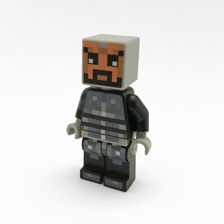

[0.51061994 0.34927675 0.14010337]
[1.0, 0.0, 0.0]


In [62]:
random_idx = random.randint(0, len(dataset)-3)

captions = dataset[random_idx:random_idx+3]["caption"]
image = dataset[random_idx]["image"]

image.resize((224, 224)).show()

print(my_model_classify(image, captions))
print(oai_model_classify(image, captions))

In [63]:
# run 100 samples and compare the results. each model returns
# a list of the 3 softmax scores for each caption, consider that
# caption 0 is always the correct one. 
# plot the results in a graph

import matplotlib.pyplot as plt

my_model_scores = []
oai_model_scores = []

for i in range(100):
    random_idx = random.randint(0, len(dataset)-3)
    captions = dataset[random_idx:random_idx+3]["caption"]
    image = dataset[random_idx]["image"]
    my_model_scores.append(my_model_classify(image, captions))
    oai_model_scores.append(oai_model_classify(image, captions))

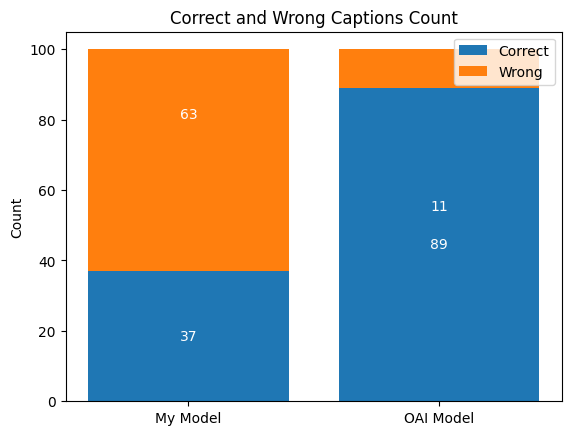

In [79]:
# plot the results showing the correct and wrong captions count for both models
# and the average score for the correct caption, for both models. Print a bar plot
# with the results

my_model_correct = 0
oai_model_correct = 0
my_model_correct_scores = []
oai_model_correct_scores = []

for my_scores, oai_scores in zip(my_model_scores, oai_model_scores):
    if my_scores[0] == max(my_scores):
        my_model_correct += 1
        my_model_correct_scores.append(my_scores[0])
    if oai_scores[0] == max(oai_scores):
        oai_model_correct += 1
        oai_model_correct_scores.append(oai_scores[0])

my_model_wrong = 100 - my_model_correct
oai_model_wrong = 100 - oai_model_correct

my_model_avg_score = sum(my_model_correct_scores) / my_model_correct
oai_model_avg_score = sum(oai_model_correct_scores) / oai_model_correct

fig, ax = plt.subplots()
ax.bar(["My Model", "OAI Model"], [my_model_correct, oai_model_correct], label="Correct")
ax.bar(["My Model", "OAI Model"], [my_model_wrong, oai_model_wrong], label="Wrong", bottom=[my_model_correct, oai_model_correct])
# add the number of correct and wrong captions
for i, correct in enumerate([my_model_correct, oai_model_correct]):
    ax.text(i, correct/2, f"{correct}", ha="center", va="center", color="white")
    ax.text(i, 100 - correct/2, f"{100 - correct}", ha="center", va="center", color="white")
ax.set_ylabel("Count")
ax.set_title("Correct and Wrong Captions Count")
ax.legend()
plt.show()